<a href="https://colab.research.google.com/github/julipolovinkina-hub/OOP_2/blob/main/OOP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==========================================
# ЭТАП 1 и 2. Базовые классы и Наследование
# ==========================================

class MenuItem:
    """Базовый класс для любой позиции в меню ресторана."""

    def __init__(self, name: str, price: float):
        self.name = name
        self.price = price

    def apply_discount(self, is_loyal: bool) -> float:
        """Полиморфный метод: базовая реализация (скидки нет)."""
        return 0.0

    def __str__(self) -> str:
        return f"{self.name} | Цена: {self.price:.2f} руб."


class Dish(MenuItem):
    """Класс блюда, наследуемый от MenuItem."""

    def __init__(self, name: str, price: float, ingredients: str):
        # Вызов конструктора родительского класса через super()
        super().__init__(name, price)
        self.ingredients = ingredients

    def apply_discount(self, is_loyal: bool) -> float:
        """Переопределение: скидка 15% на блюда для держателей карт лояльности."""
        if is_loyal:
            return self.price * 0.15
        return 0.0

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Состав: {self.ingredients}"


class Drink(MenuItem):
    """Класс напитка, наследуемый от MenuItem."""

    def __init__(self, name: str, price: float, volume_ml: int):
        super().__init__(name, price)
        self.volume_ml = volume_ml

    def apply_discount(self, is_loyal: bool) -> float:
        """Переопределение: на напитки скидка не распространяется."""
        return 0.0

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Объем: {self.volume_ml} мл"


class Customer:
    """Базовый класс посетителя ресторана."""

    def __init__(self, name: str, table_number: int):
        self.name = name
        self.table_number = table_number

    @property
    def is_loyal(self) -> bool:
        """Свойство для полиморфной проверки статуса лояльности."""
        return False

    def __str__(self) -> str:
        return f"Гость: {self.name} | Столик: №{self.table_number}"


class LoyaltyCardHolder(Customer):
    """Класс гостя с картой лояльности, наследуемый от Customer."""

    def __init__(self, name: str, table_number: int, points: int):
        super().__init__(name, table_number)
        self.points = points

    @property
    def is_loyal(self) -> bool:
        """Переопределение свойства: гость является лояльным."""
        return True

    def __str__(self) -> str:
        base_str = super().__str__()
        return f"{base_str} | Баллы лояльности: {self.points}"

In [6]:
from typing import List

# ==========================================
# ЭТАПЫ 3 и 4. Класс-контейнер (Композиция)
# ==========================================

class Check:
    """Класс чека, агрегирующий клиента и список заказанных позиций."""

    def __init__(self, customer: Customer):
        """
        Конструктор принимает объект Базового класса 2 (субъект).
        Создает пустой список для объектов Базового класса 1.
        """
        self.customer = customer
        self.items: List[MenuItem] = []

    def add_item(self, item: MenuItem) -> None:
        """Добавляет позицию меню в чек."""
        self.items.append(item)

    def calculate_total(self) -> float:
        """
        Рассчитывает итоговую сумму чека.
        Перебирает список, вызывает полиморфный метод apply_discount()
        и применяет логику, связанную со статусом клиента (Дочерний класс 2).
        """
        total = 0.0
        is_loyal = self.customer.is_loyal

        for item in self.items:
            discount = item.apply_discount(is_loyal)
            final_price = item.price - discount
            total += final_price

        return total

    def get_detailed_report(self) -> str:
        """Возвращает детализированный отчет по чеку."""
        report = [f"ЧЕК для: {self.customer.name} (Столик №{self.customer.table_number})\n" + "-" * 50]
        is_loyal = self.customer.is_loyal

        for item in self.items:
            discount = item.apply_discount(is_loyal)
            final_price = item.price - discount
            discount_str = f" (Скидка: -{discount:.2f} руб.)" if discount > 0 else ""
            report.append(f"• {item.name:<25} {final_price:>7.2f} руб.{discount_str}")

        report.append("-" * 50)
        report.append(f"ИТОГО К ОПЛАТЕ: {self.calculate_total():>29.2f} руб.")
        return "\n".join(report)

    def __str__(self) -> str:
        return f"Чек: {self.customer.name} | Позиций: {len(self.items)} | Итого: {self.calculate_total():.2f} руб."

In [7]:
# ==========================================
# ЭТАП 5. Демонстрация бизнес-сценария (main)
# ==========================================

def main() -> None:
    """Моделирование полного бизнес-процесса ресторана."""

    print("=" * 60)
    print("РЕСТОРАН 'PYTHON GOURMET' - СИСТЕМА УЧЕТА")
    print("=" * 60)

    # 1. Создаем обычного клиента и VIP-клиента (Дочерний класс 2)
    regular_guest = Customer(name="Алексей", table_number=5)
    loyal_guest = LoyaltyCardHolder(name="Мария", table_number=12, points=1250)

    print("\n--- Регистрация гостей ---")
    print(regular_guest)
    print(loyal_guest)

    # 2. Создаем набор разных товаров (объекты дочерних классов 1)
    print("\n--- Формирование меню ---")
    dish_pasta = Dish(name="Паста Карбонара", price=650.0, ingredients="Спагетти, бекон, сливки")
    dish_steak = Dish(name="Стейк Рибай", price=1800.0, ingredients="Говядина, розмарин")
    drink_wine = Drink(name="Вино красное", price=450.0, volume_ml=150)
    drink_water = Drink(name="Вода минеральная", price=150.0, volume_ml=500)

    # 3. Создаем контейнеры (Чеки) и добавляем туда товары
    print("\n--- Формирование и расчет чеков ---")

    # Чек для обычного гостя
    check_regular = Check(customer=regular_guest)
    check_regular.add_item(dish_pasta)
    check_regular.add_item(drink_wine)

    print("\n" + check_regular.get_detailed_report())
    print("Детализация: скидки не применены (гость не является держателем карты).")

    # Чек для лояльного гостя (с тем же набором блюд для наглядности)
    check_loyal = Check(customer=loyal_guest)
    check_loyal.add_item(dish_pasta)
    check_loyal.add_item(dish_steak)
    check_loyal.add_item(drink_wine)
    check_loyal.add_item(drink_water)

    print("\n" + check_loyal.get_detailed_report())
    print("Детализация: применена скидка 15% ТОЛЬКО на блюда (Паста и Стейк). Напитки без скидки.")

if __name__ == "__main__":
    main()

РЕСТОРАН 'PYTHON GOURMET' - СИСТЕМА УЧЕТА

--- Регистрация гостей ---
Гость: Алексей | Столик: №5
Гость: Мария | Столик: №12 | Баллы лояльности: 1250

--- Формирование меню ---

--- Формирование и расчет чеков ---

ЧЕК для: Алексей (Столик №5)
--------------------------------------------------
• Паста Карбонара            650.00 руб.
• Вино красное               450.00 руб.
--------------------------------------------------
ИТОГО К ОПЛАТЕ:                       1100.00 руб.
Детализация: скидки не применены (гость не является держателем карты).

ЧЕК для: Мария (Столик №12)
--------------------------------------------------
• Паста Карбонара            552.50 руб. (Скидка: -97.50 руб.)
• Стейк Рибай               1530.00 руб. (Скидка: -270.00 руб.)
• Вино красное               450.00 руб.
• Вода минеральная           150.00 руб.
--------------------------------------------------
ИТОГО К ОПЛАТЕ:                       2682.50 руб.
Детализация: применена скидка 15% ТОЛЬКО на блюда (Паста и 

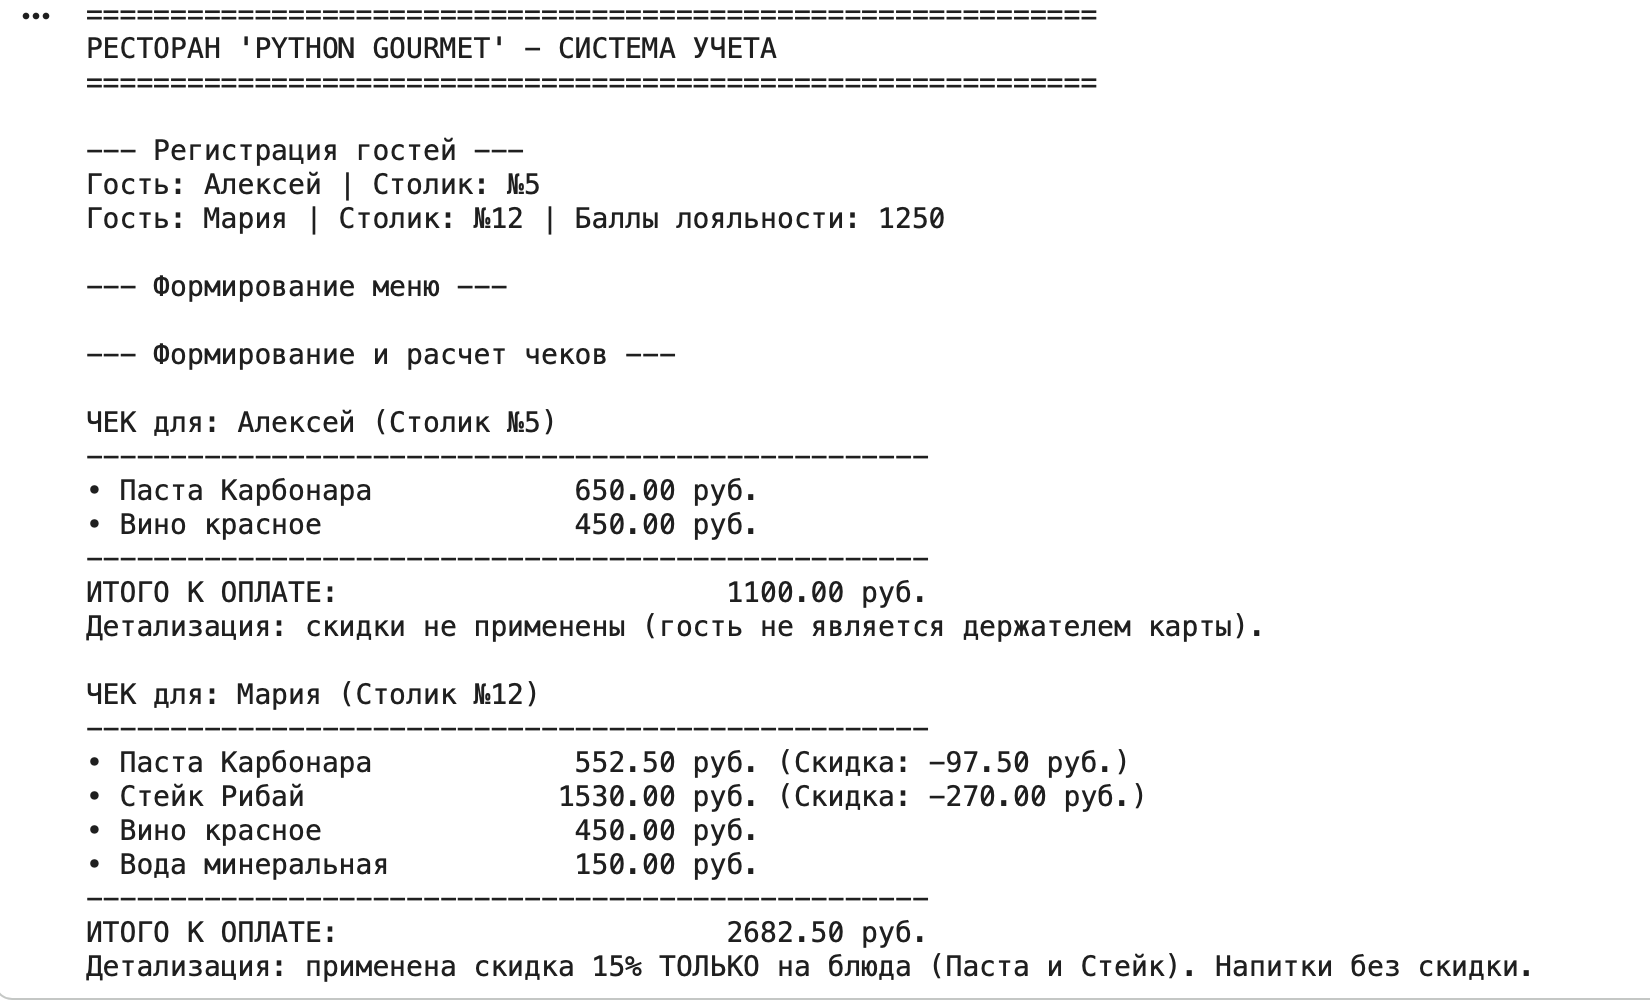